## Connect to Database
Pull the raw orders table directly.

In [1]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine(
    "mssql+pyodbc://@localhost\\SQLEXPRESS/CrownCaseBeauty_Portfolio"
    "?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)

orders_raw = pd.read_sql("SELECT * FROM orders", engine)

## Data Check
Review data and check for issues.

In [2]:
# shape and dtypes
print(orders_raw.shape)
print(orders_raw.dtypes)
orders_raw.head()

(10015, 10)
order_id               str
order_date             str
sku                    str
channel                str
units_sold           int64
unit_price         float64
discount_amount    float64
shipping_cost      float64
platform_fee       float64
return_flag            str
dtype: object


,order_id,order_date,sku,channel,units_sold,unit_price,discount_amount,shipping_cost,platform_fee,return_flag
0,ORD-100000,2024-01-19,WEAV-04-1B,Website,3,58.99,0.0,6.5,0.00,False
1,ORD-100001,2025-12-06,WIG-03-1,Website,3,23.99,0.0,6.5,0.00,False
2,ORD-100002,2024-05-02,LACE-02-2,Website,3,85.99,NaN,6.5,0.00,False
3,ORD-100003,2024-06-22,WIG-06-PINK,Website,1,32.99,0.0,6.5,0.00,False
4,ORD-100004,2025-11-28,BRAI-06-2,Amazon FBM,1,34.99,0.0,6.5,5.25,False


In [3]:
# checking for nulls
print(orders_raw.isnull().sum())

order_id             0
order_date           0
sku                  0
channel              0
units_sold           0
unit_price           0
discount_amount    500
shipping_cost      501
platform_fee         0
return_flag          0
dtype: int64


In [4]:
# looking for negatives, zeros or outliers in numeric columns
orders_raw[["unit_price", "units_sold", "discount_amount", "shipping_cost", "platform_fee"]].describe()

,unit_price,units_sold,discount_amount,shipping_cost,platform_fee
count,10015.000000,10015.000000,9515.000000,9514.0,10015.000000
mean,55.431438,2.001398,0.540357,6.5,5.676201
std,27.709832,0.817473,1.880440,0.0,10.383674
min,14.990000,1.000000,0.000000,6.5,0.000000
25%,35.990000,1.000000,0.000000,6.5,0.000000
50%,50.990000,2.000000,0.000000,6.5,0.000000
75%,65.990000,3.000000,0.000000,6.5,8.400000
max,134.990000,3.000000,13.500000,6.5,60.750000


In [5]:
# making sure only expected values show up in categorical columns
print(orders_raw["channel"].value_counts(dropna=False))
print(orders_raw["return_flag"].value_counts(dropna=False))

channel
Website       6361
Amazon FBM    3153
WEBSITE        113
WebSite        104
website         95
amazon fbm      70
Amazon fbm      64
AMAZON FBM      55
Name: count, dtype: int64
return_flag
False    9201
True      814
Name: count, dtype: int64


In [6]:
# checking for duplicates
print(orders_raw.duplicated().sum())
print(orders_raw["order_id"].duplicated().sum())

15
15


In [7]:
# checking date formats
test_parse = pd.to_datetime(orders_raw["order_date"], format="%Y-%m-%d", errors="coerce")
print(test_parse.isnull().sum())
print(orders_raw.loc[test_parse.isnull(), "order_date"].head())

200
17     10/01/2024
139    09/28/2024
181    02/12/2024
187    03/26/2025
195    10/21/2024
Name: order_date, dtype: str


In [8]:
# making sure skus appear in the products table
products_raw = pd.read_sql("SELECT * FROM products", engine)
orphan_skus = ~orders_raw["sku"].isin(products_raw["sku"])
print(orphan_skus.sum())

0


**Findings:**
- `channel`: 2 expected values (`Website`, `Amazon FBM`) with some values with different casings (e.g. `WEBSITE`, `website`, `WebSite`)
- `discount_amount`: 500 nulls
- `shipping_cost`: 501 nulls
- `order_id`: 15 duplicates
- `order_date`: 200 rows in `MM/DD/YYYY` instead of `YYYY-MM-DD`
- `return_flag`: only `True`/`False` strings, no stray values
- Numeric columns (`unit_price`, `units_sold`, `discount_amount`, `shipping_cost`, `platform_fee`): all in sane ranges, no negatives or impossible outliers
- SKUs - every `orders_raw.sku` exists in products table

## Cleaning
Fix issues found above.

In [9]:
# fixing date formats

orders_clean = orders_raw.copy()

is_mdy = orders_clean["order_date"].str.contains("/")

dates_iso = pd.to_datetime(orders_clean.loc[~is_mdy, "order_date"], format="%Y-%m-%d")
dates_mdy = pd.to_datetime(orders_clean.loc[is_mdy, "order_date"], format="%m/%d/%Y")

orders_clean["order_date"] = pd.concat([dates_iso, dates_mdy]).sort_index()

In [10]:
print(orders_clean["order_date"].min(), orders_clean["order_date"].max())

2024-01-01 00:00:00 2025-12-31 00:00:00


Date range confirmed: `2024-01-01` to `2025-12-31`, matching the expected 2-year window.

In [11]:
# fixing channel casing
orders_clean["channel"] = (
    orders_clean["channel"]
    .str.upper()
    .str.strip()
    .map({"WEBSITE": "Website", "AMAZON FBM": "Amazon FBM"})
)

In [12]:
# filling nulls
orders_clean["discount_amount"] = orders_clean["discount_amount"].fillna(0)
orders_clean["shipping_cost"] = orders_clean["shipping_cost"].fillna(6.50)

In [13]:
# dropping duplicates
orders_clean = orders_clean.drop_duplicates(subset="order_id")

In [14]:
# bool for return flags
orders_clean["return_flag"] = orders_clean["return_flag"].map({"True": True, "False": False})

In [15]:
# verify orders_clean
print(orders_clean.shape)
print(orders_clean.isnull().sum())

(10000, 10)
order_id           0
order_date         0
sku                0
channel            0
units_sold         0
unit_price         0
discount_amount    0
shipping_cost      0
platform_fee       0
return_flag        0
dtype: int64


## Feature Engineering
Engineer net_revenue and gross_margin_pct at the order level.

In [16]:
# cost of goods from products table
orders_clean = orders_clean.merge(products_raw[["sku", "cost_of_goods"]], on="sku", how="left")

In [17]:
# revenue
orders_clean["revenue"] = orders_clean["unit_price"] * orders_clean["units_sold"]
orders_clean["net_revenue"] = orders_clean["revenue"] - orders_clean["discount_amount"] - orders_clean["platform_fee"]

In [18]:
# margin
orders_clean["cost"] = orders_clean["cost_of_goods"] * orders_clean["units_sold"]
orders_clean["gross_margin_pct"] = (orders_clean["revenue"] - orders_clean["cost"] - orders_clean["platform_fee"]) / orders_clean["revenue"] * 100

**Definitions:**
- `net_revenue` = revenue − discount_amount − platform_fee 
- `gross_margin_pct` = (revenue − cost − platform_fee) / revenue

## Gross Margin
Check computed gross_margin_pct, grouped by category.

In [19]:
# category from products

orders_clean = orders_clean.merge(products_raw[["sku", "category", "product_name"]], on="sku", how="left")

In [20]:
category_margin = orders_clean.groupby("category").apply(
    lambda g: (g["revenue"].sum() - g["cost"].sum() - g["platform_fee"].sum()) / g["revenue"].sum() * 100
)
category_margin.sort_values(ascending=False)


category
Braids       28.387044
Wigs         26.939772
Weaves       26.679196
Lace Wigs    26.353029
dtype: float64

## Visualizations
### Monthly Net Revenue by Channel

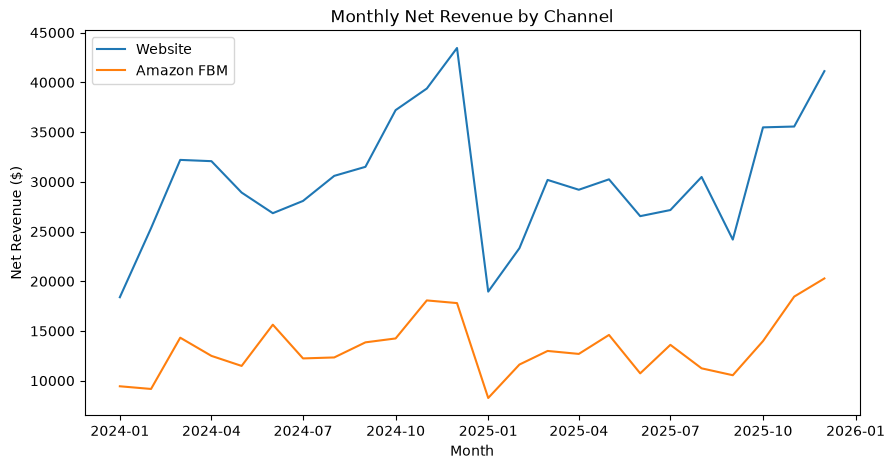

In [21]:
import matplotlib.pyplot as plt

monthly_net_revenue = (
    orders_clean.assign(month=orders_clean["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "channel"])["net_revenue"]
    .sum()
    .reset_index()
)

website_data = monthly_net_revenue[monthly_net_revenue["channel"] == "Website"]
fbm_data = monthly_net_revenue[monthly_net_revenue["channel"] == "Amazon FBM"]

plt.figure(figsize=(10, 5))
plt.plot(website_data["month"], website_data["net_revenue"], label="Website")
plt.plot(fbm_data["month"], fbm_data["net_revenue"], label="Amazon FBM")
plt.title("Monthly Net Revenue by Channel")
plt.xlabel("Month")
plt.ylabel("Net Revenue ($)")
plt.legend()
plt.show()

### Channel Revenue Share
Share of total net_revenue by channel across the full 2-year period.

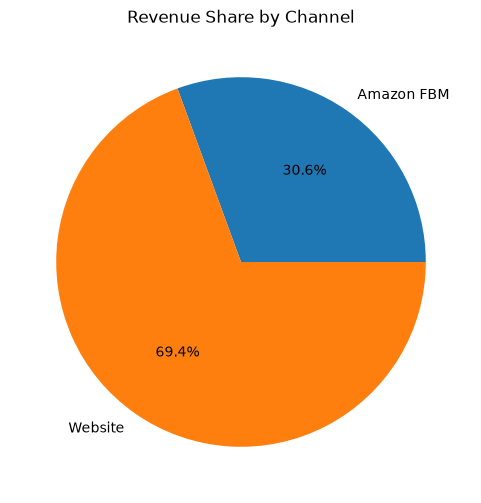

In [22]:
channel_revenue = orders_clean.groupby("channel")["net_revenue"].sum()

plt.figure(figsize=(6, 6))
plt.pie(channel_revenue, labels=channel_revenue.index, autopct="%1.1f%%")
plt.title("Revenue Share by Channel")
plt.show()

### Return Rate by Category and Channel

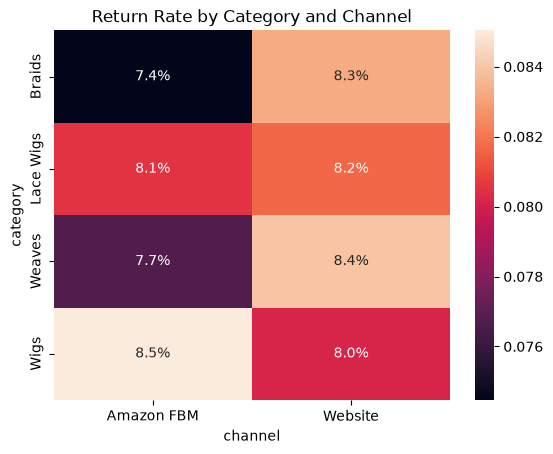

In [23]:
import seaborn as sns

return_rates = orders_clean.pivot_table(
    index="category", columns="channel", values="return_flag", aggfunc="mean"
)

sns.heatmap(return_rates, annot=True, fmt=".1%")
plt.title("Return Rate by Category and Channel")
plt.show()

### Website vs Amazon FBM Margin Gap — Top 10 SKUs by Revenue

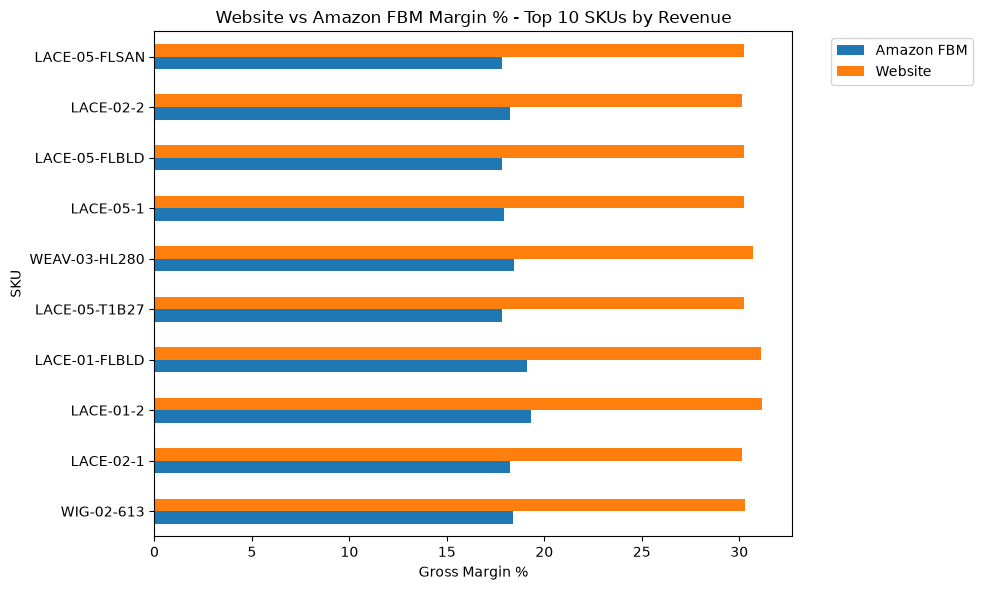

In [24]:
top_skus = orders_clean.groupby("sku")["revenue"].sum().sort_values(ascending=False).head(10).index

sku_margin = orders_clean[orders_clean["sku"].isin(top_skus)].pivot_table(
    index="sku", columns="channel", values="gross_margin_pct", aggfunc="mean"
)
sku_margin = sku_margin.reindex(top_skus)

sku_margin.iloc[::-1].plot(kind="barh", figsize=(10, 6))
plt.title("Website vs Amazon FBM Margin % - Top 10 SKUs by Revenue")
plt.xlabel("Gross Margin %")
plt.ylabel("SKU")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Return Rate by Style

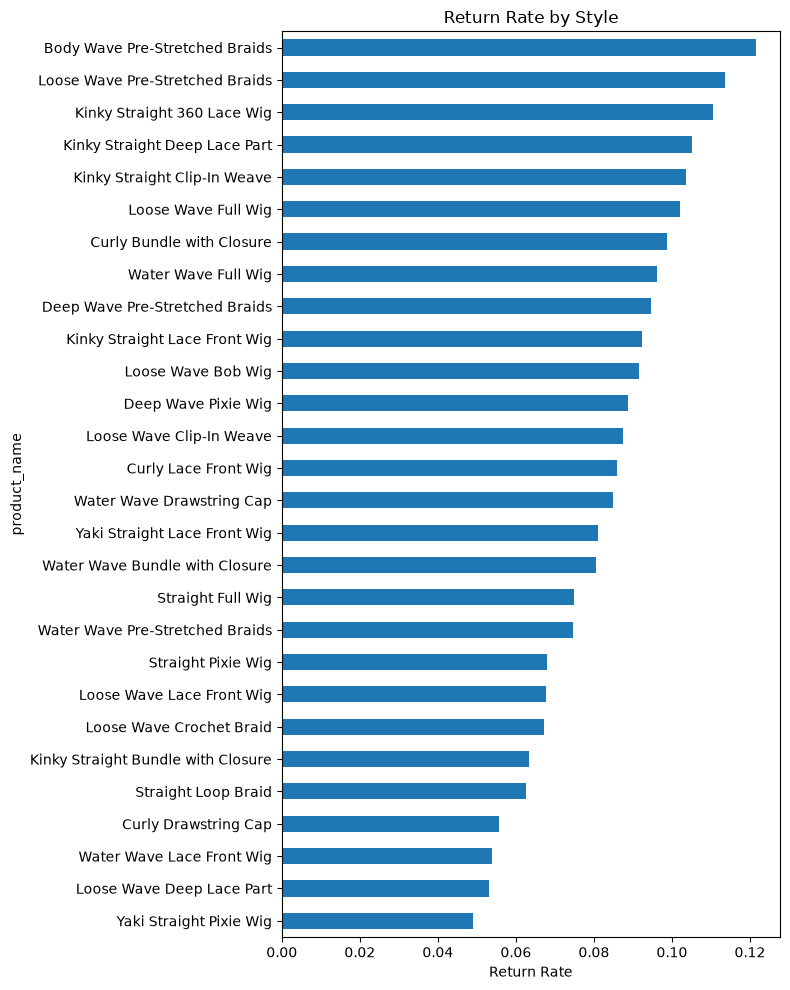

In [25]:
style_returns = orders_clean.groupby("product_name")["return_flag"].mean().sort_values(ascending=False)

style_returns.iloc[::-1].plot(kind="barh", figsize=(8, 10))
plt.title("Return Rate by Style")
plt.xlabel("Return Rate")
plt.tight_layout()
plt.show()

In [27]:
# reviewing order counts

style_stats = orders_clean.groupby("product_name")["return_flag"].agg(["mean", "count"])
style_stats.sort_values("mean", ascending=False)

,mean,count
product_name,,
Body Wave Pre-Stretched Braids,0.121622,74
Loose Wave Pre-Stretched Braids,0.113636,88
Kinky Straight 360 Lace Wig,0.110577,208
Kinky Straight Deep Lace Part,0.105263,19
Kinky Straight Clip-In Weave,0.103542,367
Loose Wave Full Wig,0.102128,470
Curly Bundle with Closure,0.098712,233
Water Wave Full Wig,0.096154,260
Deep Wave Pre-Stretched Braids,0.094718,549


**Findings:** return rates by style range from about 5% to 12%, but no real pattern by style.

### Seasonality by Category

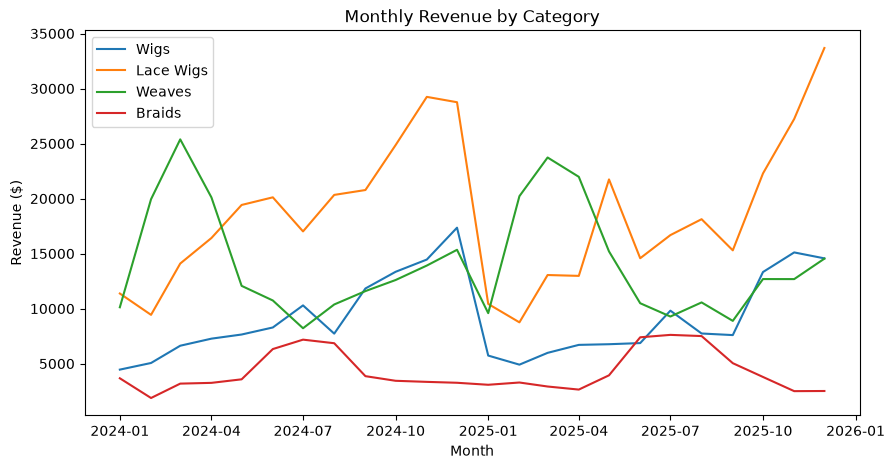

In [29]:
monthly_category_revenue = (
    orders_clean.assign(month=orders_clean["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "category"])["revenue"]
    .sum()
    .reset_index()
)

wigs_data = monthly_category_revenue[monthly_category_revenue["category"] == "Wigs"]
lace_data = monthly_category_revenue[monthly_category_revenue["category"] == "Lace Wigs"]
weaves_data = monthly_category_revenue[monthly_category_revenue["category"] == "Weaves"]
braids_data = monthly_category_revenue[monthly_category_revenue["category"] == "Braids"]

plt.figure(figsize=(10, 5))
plt.plot(wigs_data["month"], wigs_data["revenue"], label="Wigs")
plt.plot(lace_data["month"], lace_data["revenue"], label="Lace Wigs")
plt.plot(weaves_data["month"], weaves_data["revenue"], label="Weaves")
plt.plot(braids_data["month"], braids_data["revenue"], label="Braids")
plt.title("Monthly Revenue by Category")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.legend()
plt.show()

**Findings:** Wigs and Lace Wigs both peak around Nov/Dec, Weaves peaks Feb-Apr, and Braids peaks Jun-Aug, in both years.

## Export for Power BI
Save the orders table for next phase.

In [26]:
orders_clean.to_csv("../data/orders_clean.csv", index=False)